In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import transforms as T

import pytorch_lightning as pl

from torchmetrics.classification import Accuracy
from torchmetrics.aggregation import MeanMetric
from torchvision.datasets import MNIST

from datetime import datetime


from xaikd import datasets, utils, attributors

from tqdm.notebook import tqdm
from xaikd.bases import PRCAReconGreedy, PRCASignAlignGreedy, PRCASignAlignGreedyV2


from zennit.attribution import Gradient
from zennit.composites import EpsilonGammaBox

from xaikd.bases import pcalookahead



import numpy as np
import numpy.typing as npt

import os

In [2]:
!nproc

16


In [3]:
DEVICE = utils.get_device()
DEVICE

'cuda'

In [4]:
NUM_WORKERS = 16

DATA_SIZE = 0.5


In [5]:
ds_train = datasets.MultiTaskEMNISTFashionMNIST(
    train=True,
    root="../../datasets",
    transform=T.Compose(
        [
            T.ToTensor(),
            T.Normalize(
                0.5,
                0.5,
            ),
        ]
    )
)

ds_val = datasets.MultiTaskEMNISTFashionMNIST(
    train=False,
    root="../../datasets",
    transform=T.Compose(
        [
            T.ToTensor(),
            T.Normalize(
                0.5,
                0.5,
            ),
        ]
    )
)

In [6]:
TASK_NUM_CLASSES = ds_train.num_classes

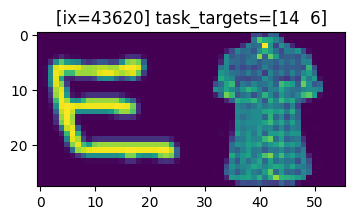

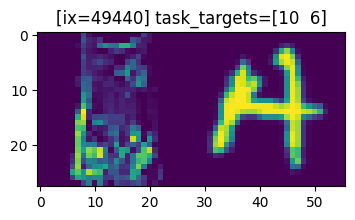

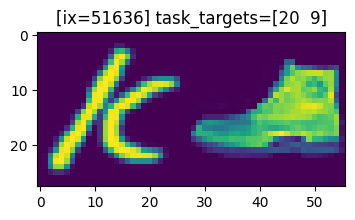

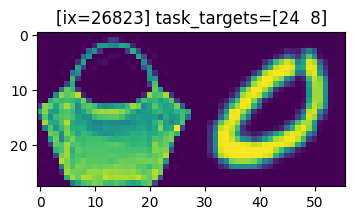

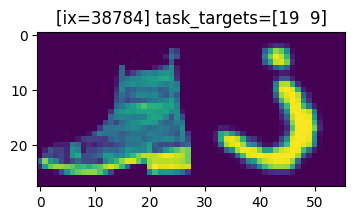

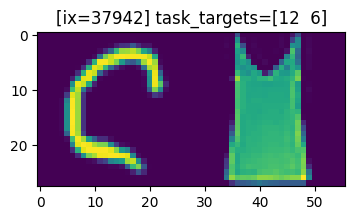

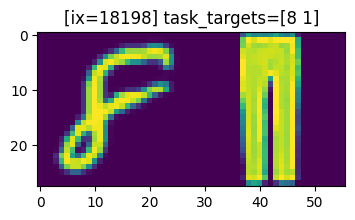

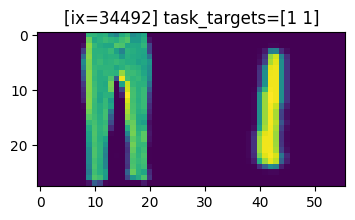

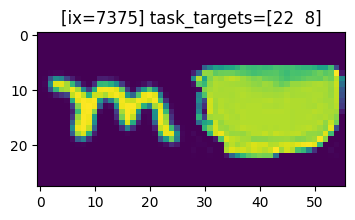

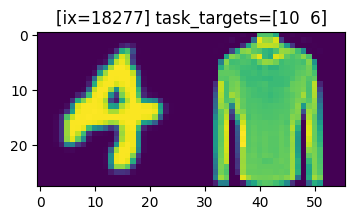

In [7]:
def ano():

    for ix in np.random.permutation(60000)[:10]:
        
        x, y = ds_train[ix]
    
        plt.figure(figsize=(2*2, 2))
        plt.imshow(x.squeeze())
        plt.title(f"[ix={ix}] task_targets={y}")
ano()

# Construct Model and Train

In [8]:
class CNN(nn.Module):
    def __init__(self, num_classes=10, d=256):
        super().__init__()
        self.conv1 = nn.Conv2d(kernel_size=3, out_channels=d, in_channels=1)
        self.act1 = nn.ReLU()
        self.max1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(kernel_size=3, out_channels=d, in_channels=d)
        self.act2 = nn.ReLU()
        self.max2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv2d(kernel_size=3, out_channels=d, in_channels=d)
        self.act3 = nn.ReLU()
        self.avgpool = nn.AdaptiveAvgPool2d(output_size=1)
        
        self.fc_task_1 = nn.Linear(d, TASK_NUM_CLASSES[0])
        self.fc_task_2 = nn.Linear(d, TASK_NUM_CLASSES[1])

    def forward(self, x):
        x = self.act1(self.conv1(x))
        x = self.max1(x)
        
        x = self.act2(self.conv2(x))
        x = self.max2(x)
        
        x = self.act3(self.conv3(x))
        
        x = self.avgpool(x)
        x = torch.flatten(x, start_dim=1)
        out_task_1 = self.fc_task_1(x)
        out_task_2 = self.fc_task_2(x)

        return out_task_1, out_task_2
    
def ano():
    
    out = CNN()(torch.randn(7, 1, 28, 28*2))
    
    print(f"santity check")
ano()

santity check


In [9]:
from torchvision.models.resnet import resnet18
from torch import nn

In [10]:
resnet18(num_classes=10);

In [11]:
class ModelWrapper(pl.LightningModule):
    def __init__(self, encoder, lr=1e-3, weight_decay=0.0):
        super().__init__()

        self.encoder = encoder
        
        self.weight_decay = weight_decay
        self.lr = lr

    def forward(self, x):
        embedding = self.encoder(x)
        return embedding

    def configure_optimizers(self):

        optimizer = torch.optim.Adam(
            self.parameters(), lr=self.lr, 
            # momentum=0.0, weight_decay=self.weight_decay
        )

        return optimizer

    def compute_metric(self, batch, prefix):

        x, y = batch

        arr_logits = self.encoder(x)

        loss = 0
        for tidx in range(2):
            y_task = y[:, tidx]
            logits_task = arr_logits[tidx]
            loss += 0.5*F.cross_entropy(
                logits_task, 
                y_task
            )

        return loss

    def training_step(self, train_batch, batch_idx):

        loss = self.compute_metric(train_batch, "train")

        self.log("train_loss", loss, on_epoch=True, prog_bar=True)
        return loss

    def summary_metric(self, prefix):

        metric = self.metrics[prefix]
        value = metric.compute()

        self.log(f"{prefix}_acc", value)

        metric.reset()

In [12]:
pl.seed_everything(1)


dl_train_noshuffle = DataLoader(
    random_split(ds_train, [DATA_SIZE, 1-DATA_SIZE])[0],
    batch_size=64,
    num_workers=NUM_WORKERS,
    # pin_memory=True,
    shuffle=False,
)

dl_test = DataLoader(
    ds_val,
    batch_size=64,
    num_workers=NUM_WORKERS,
    # pin_memory=True,
    shuffle=False,
)

dl_train = DataLoader(
    ds_train,
    batch_size=64,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    prefetch_factor=2,
    persistent_workers=True
)


model  = CNN()

trainer = pl.Trainer(
    max_epochs=50,
    accelerator=DEVICE,
    default_root_dir="/tmp"
)

# trainer.fit(ModelWrapper(model), dl_train, dl_test)
# torch.save(model.state_dict(), "./model-cnn-multinist.pth")

model.load_state_dict(
    torch.load("./model-cnn-multinist.pth")
)
model = model.to(DEVICE)

model.eval()

[rank: 0] Global seed set to 1
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


CNN(
  (conv1): Conv2d(1, 256, kernel_size=(3, 3), stride=(1, 1))
  (act1): ReLU()
  (max1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1))
  (act2): ReLU()
  (max2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1))
  (act3): ReLU()
  (avgpool): AdaptiveAvgPool2d(output_size=1)
  (fc_task_1): Linear(in_features=256, out_features=47, bias=True)
  (fc_task_2): Linear(in_features=256, out_features=10, bias=True)
)

In [13]:
def estimate_task_acc(model, dl, task_id, verbose=False):
    metric = Accuracy(task="multiclass", num_classes=TASK_NUM_CLASSES[task_id])
    metric_xent = MeanMetric()
    for x, y in tqdm(dl, disable=not verbose):
        task_logit = model(x.to(DEVICE))[task_id].detach().cpu()
        task_target = y[:, task_id]
        metric.update(task_logit, task_target)
        metric_xent.update(F.cross_entropy(task_logit, task_target))
    acc =  float(metric.compute())
    xent = float(metric_xent.compute())
    return acc, xent
def compute_accs():
    
    stats = dict()
    
    for tidx in tqdm(range(2)):
        
        for label, dl in [
            # ("train", dl_train_noshuffle),
            ("test", dl_test)
        ]:            
            stats[f"acc_task_{tidx}_{label}"], stats[f"xent_task_{tidx}_{label}"] = estimate_task_acc(model, dl, tidx)
    
    return stats

ref_stats = compute_accs()
ref_stats

  0%|          | 0/2 [00:00<?, ?it/s]

{'acc_task_0_test': 0.8428000211715698,
 'xent_task_0_test': 0.5066717267036438,
 'acc_task_1_test': 0.8921999931335449,
 'xent_task_1_test': 0.33956974744796753}

# LRP Checking

In [14]:
GAMMA = 0.01

sanity_check: passed


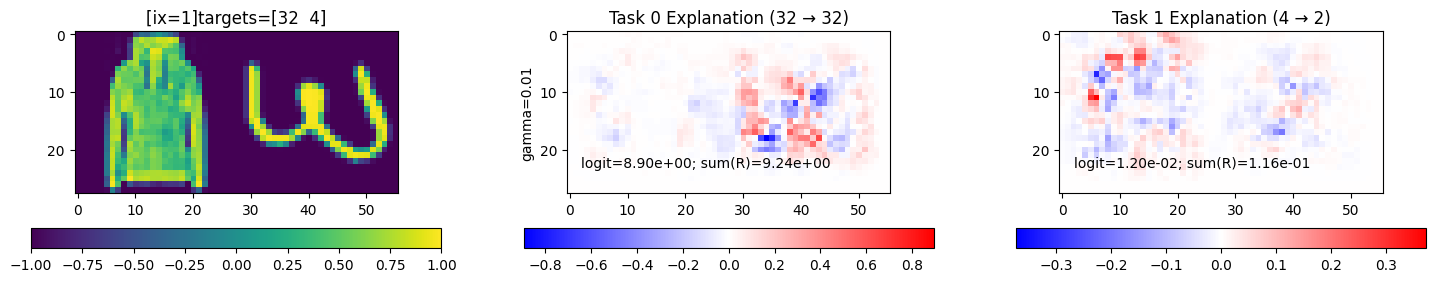

In [15]:


class TaskSpecificHeadModel(nn.Module):
    def __init__(self, model, task_id: int):
        super().__init__()
        self.model = model
        self.task_id = task_id 

    def forward(self, x):
        return self.model(x)[self.task_id]

def make_attributor(model):
    
    low = torch.tensor([-1.])
    high = torch.tensor([1.])

    composite = EpsilonGammaBox(low=low, high=high, gamma=GAMMA)

    return Gradient(model=model, composite=composite)


def sanity_check():

    task_id = 0

    logit_modifier = attributors.WinningClassEvidence(num_classes=TASK_NUM_CLASSES[task_id])
    task_specific_model = TaskSpecificHeadModel(model, task_id=task_id)
    with make_attributor(task_specific_model) as attributor:
        x = torch.randn((7, 1, 28, 28*2)).to(DEVICE)
        
        _ = attributor.forward(x, lambda logits: logit_modifier(logits, None))
    print("sanity_check: passed")

sanity_check()

def viz_explain_tasks(sample_ix):

    ncols = 3
    plt.figure(figsize=(6*ncols, 3))

    x, y = ds_val[sample_ix]
    x = x.unsqueeze(0).to(DEVICE)

    plt.subplot(1, 3, 1)
    plt.title(f"[ix={sample_ix}]targets={y}")

    plt.imshow(x.detach().cpu().numpy().squeeze())
    plt.colorbar(location="bottom")
    for task_id in [0, 1]:
        task_specific_model = TaskSpecificHeadModel(model, task_id=task_id)
        
        with make_attributor(task_specific_model) as attributor:

            task_logits, heatmap = attributor.forward(
                x, 
                lambda logits: logits * F.one_hot(torch.tensor([y[task_id]]), num_classes=TASK_NUM_CLASSES[task_id]).to(logits.device)
            )

            task_logits = task_logits.detach().cpu().numpy()
            pred = np.argmax(task_logits)

            plt.subplot(1, ncols, task_id + 2)

            plt.title(f"Task {task_id} Explanation ({y[task_id]} → {pred})")
            if task_id == 0:
                plt.ylabel(f"gamma={GAMMA}")
            heatmap = heatmap.cpu().detach().numpy().squeeze()
            plt.text(2, 28-5, f"logit={task_logits[0, y[task_id]]:.2e}; sum(R)={heatmap.sum():.2e}")
            vmax = np.abs(heatmap).max()
            plt.imshow(heatmap, cmap="bwr", vmin=-vmax, vmax=vmax)
            plt.colorbar(location="bottom")
    
viz_explain_tasks(1)

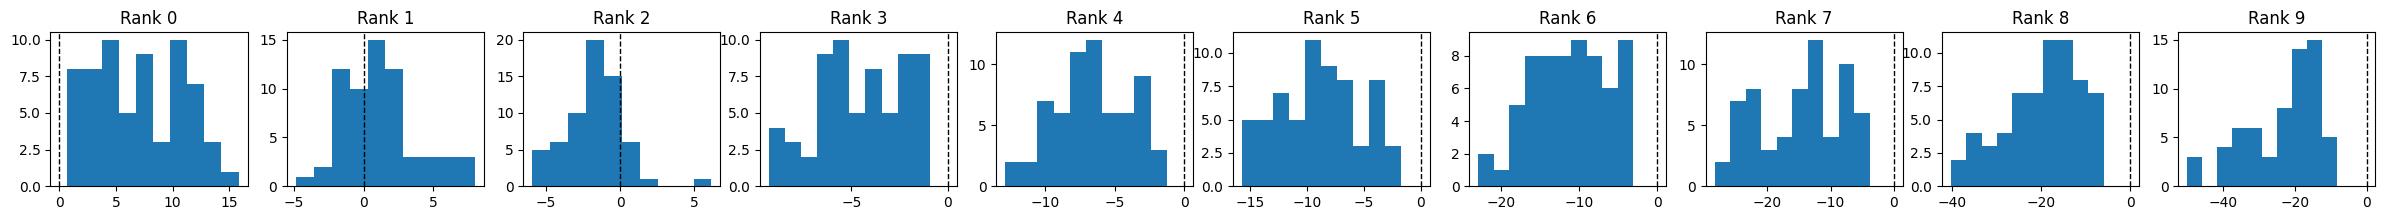

In [16]:
@torch.no_grad()
def check_winning_logits():

    ncols = 10
    task_id = 1
    plt.figure(figsize=(ncols*3, 2))
    for rank_ix in range(ncols):
        plt.subplot(1, ncols, rank_ix + 1)
        plt.title(f"Rank {rank_ix}")
        arr_winning_logits = []
        
        for x, _ in dl_train_noshuffle:
            logits = model(x.to(DEVICE))[task_id].detach().cpu()
            _, nc = logits.shape
            
            _, indices = torch.topk(logits, dim=1, k=ncols)
            one_hot = F.one_hot(
                indices[:, rank_ix], 
                num_classes=nc
            )
    
            rank_logits = (one_hot * logits).sum(dim=1)
            
            arr_winning_logits.extend(rank_logits.numpy().tolist())
    
            break
        plt.axvline(0, ls="--", lw=1, color="k")
        plt.hist(arr_winning_logits)
check_winning_logits()

# Extract Act and Ctx

In [17]:
ARR_LAYERS = ["max1", "max2", "act3"]

ARR_LAYERS

['max1', 'max2', 'act3']

In [18]:
model

CNN(
  (conv1): Conv2d(1, 256, kernel_size=(3, 3), stride=(1, 1))
  (act1): ReLU()
  (max1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1))
  (act2): ReLU()
  (max2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1))
  (act3): ReLU()
  (avgpool): AdaptiveAvgPool2d(output_size=1)
  (fc_task_1): Linear(in_features=256, out_features=47, bias=True)
  (fc_task_2): Linear(in_features=256, out_features=10, bias=True)
)

In [19]:
from collections import OrderedDict

In [20]:
def split_model_for_task(model, layer, task_id):

    arr_name_layers = list(model.named_children())

    layer_names = list(map(lambda t: t[0], arr_name_layers))
    layer_ix = layer_names.index(layer)
    avgpool_ix = layer_names.index("avgpool")


    task_module_name = f"fc_task_{task_id+1}"
    
    task_module = getattr(model, task_module_name)

    first_module = nn.Sequential(OrderedDict(
        arr_name_layers[:layer_ix+1]
    ))
    second_module = nn.Sequential(OrderedDict(
        arr_name_layers[layer_ix+1:avgpool_ix+1] 
        + [
            ("flatten", nn.Flatten(start_dim=1)),
            (task_module_name, task_module)
        ]
    ))
    
    return first_module, second_module

@torch.no_grad()
def ano():


    trng = torch.Generator()
    trng.manual_seed(1)
    
    x = torch.randn(10, 1, 28, 56, generator=trng).to(DEVICE)
    
        
    for task_id in [0, 1]:
        for layer in ARR_LAYERS:
            m1, m2 = split_model_for_task(model, layer, task_id)

            actual = m2(m1(x)).cpu().numpy()
            expected = model(x)[task_id].cpu().numpy()
            np.testing.assert_allclose(
                actual,
                expected
            )
            print(f"sanity check: task_id={task_id} layer={layer} passed!")
ano()

sanity check: task_id=0 layer=max1 passed!
sanity check: task_id=0 layer=max2 passed!
sanity check: task_id=0 layer=act3 passed!
sanity check: task_id=1 layer=max1 passed!
sanity check: task_id=1 layer=max2 passed!
sanity check: task_id=1 layer=act3 passed!


In [21]:
class PositiveWinnerNegativeOthersEvidence(attributors.LogitModifier):
    def __init__(self, num_classes: int) -> None:
        self.num_classes = num_classes

    def __call__(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        logits = logits.clone()
        wining_targets = torch.argmax(logits, dim=1)

        selecting_winner = F.one_hot(wining_targets, self.num_classes).to(
            logits.device
        )

        winning_logit = selecting_winner * logits 

        other_logits = (1-selecting_winner)  * logits

        return  winning_logit - other_logits.abs()
        

class PositiveWinnerNegativeOthersOneHotEvidence(attributors.LogitModifier):
    def __init__(self, num_classes: int) -> None:
        self.num_classes = num_classes

    def __call__(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        logits = logits.clone()
        wining_targets = torch.argmax(logits, dim=1)

        selecting_winner = F.one_hot(wining_targets, self.num_classes).to(
            logits.device
        )

        winning_logit = selecting_winner 

        other_logits = (1-selecting_winner) 

        return  winning_logit - other_logits.abs()
        


class DifferenceTop2WinningClassesEvidence(attributors.LogitModifier):
    def __init__(self, num_classes: int) -> None:
        self.num_classes = num_classes

    def __call__(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        logits = logits.clone()
        # find the label of two winning classes
        _, indices = torch.topk(logits, dim=1, k=2)
        return logits * F.one_hot(indices[:, 0], self.num_classes) - logits.abs() * F.one_hot(
            indices[:, 1], self.num_classes
        )

class Top2WinningClassesEvidence(attributors.LogitModifier):
    def __init__(self, num_classes: int) -> None:
        self.num_classes = num_classes

    def __call__(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        logits = logits.clone()
        # find the label of two winning classes
        _, indices = torch.topk(logits, dim=1, k=2)
        return logits * F.one_hot(indices[:, 0], self.num_classes) + logits * F.one_hot(
            indices[:, 1], self.num_classes
        )

    def __str__(self) -> str:
        return "contrasttop2"

class WinningClassAtIndexEvidence(attributors.LogitModifier):
    def __init__(self, winning_index:int, num_classes: int) -> None:
        self.num_classes = num_classes
        self.winning_index = winning_index

    def __call__(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        logits = logits.clone()
        # find the label of two winning classes
        _, indices = torch.topk(logits, dim=1, k=2)
        return logits * F.one_hot(indices[:, self.winning_index], self.num_classes)



def compute_log_odd_winning(logits: torch.Tensor) -> torch.Tensor:

    ns, nc = logits.shape

    values, _ = torch.topk(logits, dim=1, k=nc)

    logit_winning = values[:, 0]
    lse_others = torch.logsumexp(values[:, 1:], dim=1)
    log_odd = logit_winning - lse_others

    return log_odd


class LogOddWinning(attributors.LogitModifier):
    def __init__(self) -> None:
        pass
    def __call__(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        log_odd =  compute_log_odd_winning(logits)

        assert torch.isfinite(log_odd).all()
        
        return log_odd


class LogOddWinningForLRP(attributors.LogitModifier):
    def __init__(self) -> None:
        pass
    def __call__(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:

        ns, nc = logits.shape
        logits = logits.clone()

        logits.requires_grad_(True)
        
        log_odd =  compute_log_odd_winning(logits)

        assert log_odd.shape == (ns,), log_odd.shape

        # todo: cross-check this is the quantity we want!
        relevance = torch.autograd.grad(
            log_odd.sum(),
            logits
        )[0]
        
        assert relevance.shape == logits.shape, relevance.shape
        assert torch.isfinite(relevance).all()
  
        return logits * relevance

In [23]:
class VoidAttributor:

    def __enter__(self, **kwargs):
        pass

    def __exit__(self, type, value, tb):
        pass

        
def extract_activation_context(
    model: nn.Module,
    layer: str,
    data_loader: DataLoader,
    task_id: int,
    logit_mod_name: str,
    rng: np.random.Generator,
    use_lrp: bool,
    device="cpu",
    number_of_selected_spatial_locations=20,
    strict_mode=False,
    verbose=False,
):
    arr_act = []
    arr_ctx = []

    num_classes = TASK_NUM_CLASSES[task_id]
    
    if logit_mod_name == "winning-class":
        logit_mod = attributors.WinningClassEvidence(num_classes=num_classes)
    elif logit_mod_name == "winning-class-onehot":
        logit_mod = attributors.WinningClassOneHotEvidence(num_classes=num_classes)
    elif logit_mod_name == "pos-winner-neg-others":
        logit_mod = PositiveWinnerNegativeOthersEvidence(num_classes=num_classes)
    elif logit_mod_name == "pos-winner-neg-others-onehot":
        logit_mod = PositiveWinnerNegativeOthersOneHotEvidence(num_classes=num_classes)
    elif logit_mod_name == "diff-top2winner":
        logit_mod = DifferenceTop2WinningClassesEvidence(num_classes=num_classes)
    elif logit_mod_name == "all-classes":
        logit_mod = attributors.ALlClassesEvidence(num_classes=num_classes)
    elif logit_mod_name == "winning-0":
        logit_mod = WinningClassAtIndexEvidence(num_classes=num_classes, winning_index=0)
    elif logit_mod_name == "winning-1":
        logit_mod = WinningClassAtIndexEvidence(num_classes=num_classes, winning_index=1)
    elif logit_mod_name == "LogOddWinning":
        logit_mod = LogOddWinning()
    elif logit_mod_name == "LogOddWinningForLRP":
        logit_mod = LogOddWinningForLRP()
    else:
        raise NotImplemented(f"logit_mod={LOGIT_MOD} doesn't exist")


    try:
        module, hook = utils.interceptor.attach_hook_intercept_layer_output(
            model, layer, should_retain_grad=True, detach_output=False
        )

        task_specific_head = TaskSpecificHeadModel(model, task_id=task_id)

        
        attributor = make_attributor(task_specific_head) if use_lrp else VoidAttributor()
        
        with attributor:
            for batch in tqdm(data_loader, desc=f"extract act ctx (use_lrp={use_lrp}; logit_mod={logit_mod_name}) at layer={layer}"):
                x, y = batch
                x = x.to(device)



                if use_lrp:
                    _ = attributor.forward(x, lambda logits: logit_mod(logits, y))

                    act = utils.interceptor.get_output(module)
                    assert act.grad is not None

                    rel = act.grad
    
                    output_dimensions = act.shape[1:]
    
                    ctx = torch.where(act.abs() > 0, rel / act, 0)
    
                    if strict_mode:
                        np.testing.assert_allclose(
                            (act * ctx).detach().cpu().numpy(),
                            rel.detach().cpu().numpy(),
                            atol=1e-6,
                        )

                else:
                    
                    logits = task_specific_head(x)
                    (logit_mod(logits, y)).sum().backward()
                    act = utils.interceptor.get_output(module)
                    output_dimensions = act.shape[1:]

                    assert act.grad is not None
                    ctx = act.grad

                assert ctx.shape == act.shape

                
                act = act.detach().cpu().numpy()
                ctx = ctx.detach().cpu().numpy()

                selected_act, selected_ctx = utils.subsample_tensors(
                    act,
                    ctx,
                    num_locations=number_of_selected_spatial_locations,
                    rng=rng,
                )
                arr_act.append(selected_act)
                arr_ctx.append(selected_ctx)

    finally:
        hook.remove()

    print(f"{layer}: output-dims={output_dimensions}")

    arr_act = np.vstack(arr_act)
    arr_ctx = np.vstack(arr_ctx)

    return arr_act, arr_ctx


def extract_act_grad(model, layer, logit_mod_name, dl, task_id, use_lrp):
    


    return extract_activation_context(
        model=model,
        layer=layer,
        data_loader=dl_train_noshuffle,
        task_id=task_id,
        logit_mod_name=logit_mod_name,
        rng=np.random.default_rng(seed=1),
        device=DEVICE,
        use_lrp=use_lrp
    )

extract_act_grad(model, "max2", "diff-top2winner", dl_train_noshuffle, 0, use_lrp=True)
# extract_act_grad(model, "act3", "winning-0", dl_train_noshuffle, 0, use_lrp=False)

extract act ctx (use_lrp=True; logit_mod=diff-top2winner) at layer=max2:   0%|          | 0/469 [00:00<?, ?it/…

max2: output-dims=torch.Size([256, 5, 12])


(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], dtype=float32),
 array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], dtype=float32))

In [24]:
def sanity_check():
    arr_act, _ = extract_act_grad(model, dl_train_noshuffle, 0)
    
    for tidx in [1]:
        arr_act_other, _ = extract_act_grad(model, dl_train_noshuffle, tidx)
        np.testing.assert_allclose(
            arr_act_other,
            arr_act
        )
        print(f"arr_act(T0) == arr_act(T{tidx})")
    print("all passed!")

# sanity_check()

# Basis Construction

In [26]:
BASES = dict()

def register_basis():
    """Decorator to register a data modality provider."""

    def wrapped(cls):
        """Wrapped function to register a data modality provider with name `name`"""
        name = cls.__name__
        BASES[name] = cls

        return cls

    return wrapped

def _solve_eigvecs(cov, sort_func=lambda x: x):
    eigvals, eigvecs = np.linalg.eigh(cov)

    assert len(eigvals.shape) == 1

    indices = np.argsort(-sort_func(eigvals))
    eigvals = eigvals[indices]
    eigvecs = eigvecs[:, indices]

    return eigvecs, eigvals

## Baseline

In [30]:

class BasisInterface:
    def get_Uk(self, k: int) -> npt.NDArray:
        raise NotImplementedError()   

@register_basis()
class PCABasis(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):
        cov = arr_act.T @ arr_act
        self.U, self.eigvals = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]

@register_basis()
class GradPCABasis(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):
        cov = arr_ctx.T @ arr_ctx
        self.U, self.eigvals = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]

@register_basis()
class PRCASortAbsBasis(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):
        cov = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act
        self.U, self.eigvals = _solve_eigvecs(cov, sort_func=np.abs)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]


@register_basis()
class PRCAPosDefBasis(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):

        pca = PCABasis(arr_act=arr_act, arr_ctx=arr_ctx)
        gradpca = GradPCABasis(arr_act=arr_act, arr_ctx=arr_ctx)
        
        arr_act = arr_act / ( np.sum(pca.eigvals) ** 0.5)
        arr_ctx = arr_ctx / ( np.sum(gradpca.eigvals) ** 0.5)


        cov_a = 2*(arr_act.T @ arr_act)
        cov_c = 2*(arr_ctx.T @ arr_ctx)
        cov_ac = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act
        
        cov = cov_ac + cov_a + cov_c
        
        self.U, self.eigvals = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]


@register_basis()
class PRCABasis(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):
        cov = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act
        self.U, _ = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]

# Estimate Statistics

In [43]:
def construct_fh(Uk):
    def fh(mod, inp, outp):
        return F.conv2d(
            outp,
            (Uk@Uk.T).unsqueeze(2).unsqueeze(3)
        )
    return fh

def compute_task_acc_at_k(
    model, layer, task_id, 
    arr_ks,
    use_lrp,
    arr_basis_names=["PCABasis", "PRCASortAbsBasis"],
    base_output_dir="./artifacts/multinist",
    logit_mod_name = "winning-class"
):
    arr_act, arr_ctx = extract_act_grad(model, layer, logit_mod_name, dl_train_noshuffle, task_id, use_lrp=use_lrp)

    
    module = getattr(model, layer)

    rel = (arr_act  * arr_ctx).sum(axis=1)

    suffix = "relevance-lrp" if use_lrp else "relevance-grad"
    output_path = f"{base_output_dir}/task-{task_id}/{layer}/{suffix}"
    # os.makedirs(output_path, exist_ok=True)

    arr_dfs = []

    for basis_name in arr_basis_names:
        basis: BasisInterface = BASES[basis_name](
            arr_act=arr_act, 
            arr_ctx=arr_ctx,
            layer=layer,
            task_id=task_id
        )
        
        arr_stat_rows = []

        for k in tqdm(
            arr_ks, 
            desc=f"[{basis_name:<20s}] Estimating Performance"
        ):

            Uk = basis.get_Uk(k=k)

            arr_recon_act = (arr_act @ Uk) @ Uk.T

            recon_err = np.linalg.norm(arr_act - arr_recon_act, axis=1).mean()
            projected_rel = ((arr_act @ Uk) * (arr_ctx @ Uk)).sum(axis=1)
            rel_recon_err = ((rel - projected_rel) **2).mean()
            assert rel.shape == projected_rel.shape == (rel.shape[0], )
            perc_sign_align = (np.sign(rel) * np.sign(projected_rel)).mean()
            
            Uk = torch.from_numpy(Uk).to(DEVICE)
            row = dict(
                layer=layer,
                task_id=task_id, 
                logit_mod=logit_mod_name,
                gamma=GAMMA,
                k=k, 

                basis_name=basis_name,
                recon_err=recon_err,
                rel_recon_err=rel_recon_err,
                perc_sign_align=perc_sign_align,
            )
            try:
                hook = module.register_forward_hook(construct_fh(Uk))
                
                for label, dl in [
                    ("test", dl_test)
                ]:
                    row[f"acc_{label}"], row[f"xent_{label}"] = estimate_task_acc(model, dl, task_id)
                
            finally:
                hook.remove()
            arr_stat_rows.append(row)
            
        df = pd.DataFrame(arr_stat_rows)
        # df.to_csv(
        #     f"{output_path}/{basis_name}.csv",
        #     index=False
        # )

        arr_dfs.append(df)

    df = pd.concat(arr_dfs).sort_values(by=["k", "acc_test"], ascending=[True, False])
    print(f"Checking results at {output_path}")
    return df


# logit_mod_list = winning-class, pos-winner-neg-others, pos-winner-neg-others-onehot, diff-top2winner, all-classes
    

compute_task_acc_at_k(
    model, layer="act3", 
    task_id=0, 
    arr_ks=[5, 10],
    use_lrp=True,
    base_output_dir="./tmp",
    logit_mod_name="diff-top2winner",
    arr_basis_names=[ 
        # "PCABasis",
        "GradPCABasis",
        # "PRCABasis",
        # "PRCASortAbsBasis",
        # "PRCAPosDefBasis",
     ]
)

extract act ctx (use_lrp=True; logit_mod=diff-top2winner) at layer=act3:   0%|          | 0/469 [00:00<?, ?it/…

act3: output-dims=torch.Size([256, 3, 10])


[GradPCABasis        ] Estimating Performance:   0%|          | 0/2 [00:00<?, ?it/s]

Checking results at ./tmp/task-0/act3/relevance-lrp


,layer,task_id,logit_mod,gamma,k,basis_name,recon_err,rel_recon_err,perc_sign_align,acc_test,xent_test
0,act3,0,diff-top2winner,0.01,5,GradPCABasis,63.090866,0.710790,0.40485,0.1594,3.802977
1,act3,0,diff-top2winner,0.01,10,GradPCABasis,59.783234,0.516568,0.45796,0.3357,3.221021


# Computing Results

In [38]:
def get_dims(layer):
    return {
        "max1": 256,
        "max2": 256,
        "act3": 256,
    }[layer]

# Accuracy Curves

In [46]:
def collect_stats():
    arr_dfs = []
    use_lrp = False,
    logit_mod_name = "diff-top2winner"
    
    arr_basis_names=[
            "PCABasis",
            "GradPCABasis",
            "PRCASortAbsBasis",
            "PRCAPosDefBasis",
    ]
    for layer in tqdm(["act3", "max2", "max1"]):
        d = get_dims(layer)

        arr_ks = np.linspace(1, d // 4, 10).astype(int).tolist() + [d]

        for task_id in [0, 1]:
            df = compute_task_acc_at_k(
                model, layer=layer, task_id=task_id, logit_mod_name=logit_mod_name, arr_ks=arr_ks,
                arr_basis_names=arr_basis_names, use_lrp=use_lrp
            )
            arr_dfs.append(df)

    return pd.concat(arr_dfs)

df = collect_stats()

  0%|          | 0/3 [00:00<?, ?it/s]

extract act ctx (use_lrp=(False,); logit_mod=diff-top2winner) at layer=act3:   0%|          | 0/469 [00:00<?, …

act3: output-dims=torch.Size([256, 3, 10])


[PCABasis            ] Estimating Performance:   0%|          | 0/11 [00:00<?, ?it/s]

[GradPCABasis        ] Estimating Performance:   0%|          | 0/11 [00:00<?, ?it/s]

...

[PCABasis            ] Estimating Performance:   0%|          | 0/11 [00:00<?, ?it/s]

[GradPCABasis        ] Estimating Performance:   0%|          | 0/11 [00:00<?, ?it/s]

[PRCASortAbsBasis    ] Estimating Performance:   0%|          | 0/11 [00:00<?, ?it/s]

[PRCAPosDefBasis     ] Estimating Performance:   0%|          | 0/11 [00:00<?, ?it/s]

Checking results at ./artifacts/multinist/task-1/max1/relevance-lrp


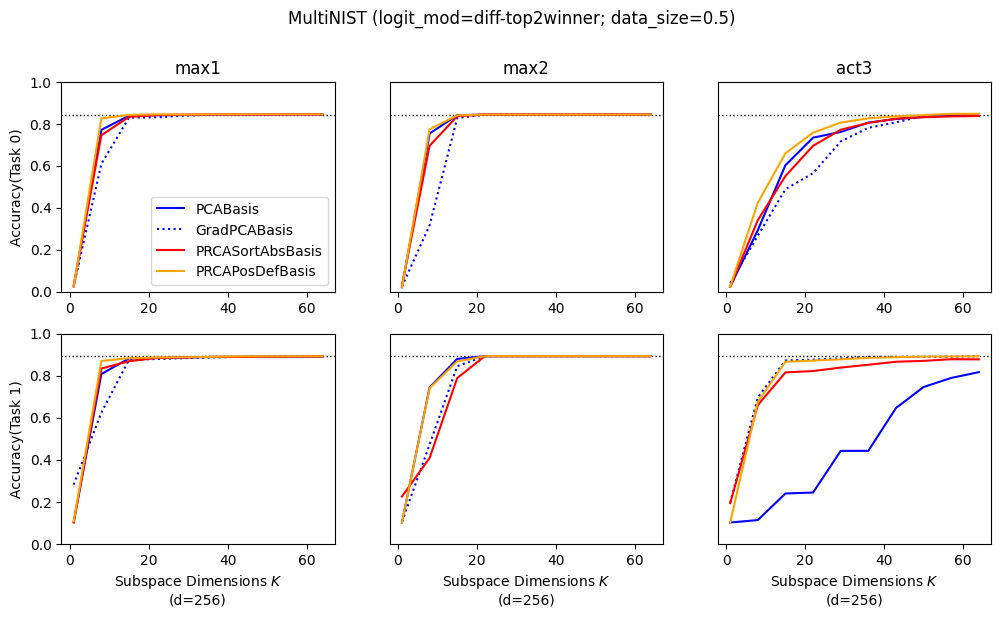

In [69]:

def ls_color(basis_name):
    return {
        "PCABasis": ("-", "blue"),
        "GradPCABasis": (":", "blue"),
        "PRCASortAbsBasis": ("-", "red"),
        "PRCAPosDefBasis": ("-", "orange"),
    }.get(basis_name, (None, None))

        
def viz(
    df,
    use_lrp=False,
):

    arr_layers = ["max1", "max2", "act3"]
    
    arr_task_ids = sorted(df.task_id.unique())
    nrows = len(arr_task_ids)
    ncols = len(arr_layers)
    
    plt.figure(figsize=(4*ncols, 3*nrows))

    arr_basis_names = [
        "PCABasis",
        "GradPCABasis",
        "PRCASortAbsBasis",
        "PRCAPosDefBasis",
    ]
    
    logit_mod_name = df.logit_mod.values[0]
    

    arr_pca_lh_names = list(filter(lambda t: "pca-lh" in t, arr_basis_names))


    plt.suptitle(f"MultiNIST (logit_mod={logit_mod_name}; data_size={DATA_SIZE})", y=1.0)
    
    for task_id in arr_task_ids:

        for lix, layer in enumerate(arr_layers):
            d = get_dims(layer)

            plt.subplot(nrows, ncols, task_id*ncols+lix + 1)
            if task_id == 0:
                plt.title(layer)
            
            for bix, basis_name in enumerate(arr_basis_names):
                _df = df[
                    (df.basis_name == basis_name) 
                    & (df.task_id == task_id) \
                    & (df.layer == layer) \
                ]
                assert len(_df) > 0
                if bix == 0:
                    
                    ref = ref_stats[f"acc_task_{task_id}_test"]
    
                    plt.axhline(
                        ref,
                        ls=":",
                        lw=1,
                        color="k",
                    )

                ls, color = ls_color(basis_name)
                selected = _df.k <= 64
                
                for label in ["test"]:
                    plt.plot(
                        _df.k[selected],
                        _df[f"acc_{label}"][selected],
                        color=color,
                        ls=ls,
                        marker=marker(basis_name),
                        label=f"{basis_name}"
                    )
                plt.ylim([0.0, 1.])
                if lix == 0:
                    if task_id == 0:
                        plt.legend()
                    plt.ylabel(f"Accuracy(Task {task_id})")
                else:
                    plt.yticks([])

                if task_id == 1:
                    plt.xlabel(f"Subspace Dimensions $K$\n(d={d})")
                
viz(df=df)

In [70]:
print(f"Finished at {datetime.now()}")

Finished at 2025-02-05 23:28:02.792898
